<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%208%20-%20Cameron's%20Version/regime%201%20-%20CelebA/CelebA%20-%2003_three_factor_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 8 — regime 1 (CelebA) · Three-factor clean (cos≈0.5)
From-scratch ViT (P≈1.01M), 40-attribute multi-label classification; loss = BCE, metric = mean per-attribute accuracy.

## Step 0 — Setup

In [14]:
import os, time, math, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Built for an A100 Colab runtime; set SMOKE=True to sanity-check on CPU.')

torch 2.11.0+cu128 | device: cuda


## Config

In [15]:
METHOD = 'three_factor_clean'
SIGMA = 1e-2
TARGET_COS = 0.5   # M chosen so cos(g_hat, grad) ~ this
CHUNK_PROBES = 64    # vmap probe-batch = memory knob (same estimate, more loop iters); 64px CelebA OOMs at 256
LR_LOCAL = 0.05
MOMENTUM = 0.9
CLIP_GRAD_NORM = 1.0
METHOD_CFG = dict(SIGMA=SIGMA, TARGET_COS=TARGET_COS, CHUNK_PROBES=CHUNK_PROBES, LR_LOCAL=LR_LOCAL, MOMENTUM=MOMENTUM, CLIP_GRAD_NORM=CLIP_GRAD_NORM)


# =============================== CONFIG (shared across the 5 methods) ===============================
# From-scratch ViT, IDENTICAL for every method (the only fair race). P ~ 1.01M.
IMG, PATCH, IN_CH, NUM_CLASSES = 64, 8, 3, 40      # CelebA 64x64 RGB; 40-attribute multi-label
EMBED_DIM, DEPTH, HEADS, MLP_RATIO = 176, 4, 8, 2
DRIVE_SUBDIR = 'Section8_r1_celeba'
TIME_BUDGET_HOURS = 2.0
BATCH             = 64
SEED              = 0
EVAL_BATCH        = 2000
LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC = 30, 120, 1800
USE_DRIVE = True


SMOKE = False
if SMOKE:                                     # tiny end-to-end CPU check
    EMBED_DIM, DEPTH, HEADS = 32, 1, 2
    TIME_BUDGET_HOURS = 20/3600
    LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC = 2, 5, 999
    EVAL_BATCH, USE_DRIVE = 1000, False
# ===================================================================================================

## Step 1 — Storage (Drive) + paths

In [16]:
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        STORE = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed -> local /content (will NOT survive disconnect):', e)
        STORE = os.path.join('/content', DRIVE_SUBDIR)
else:
    STORE = os.path.join('.', DRIVE_SUBDIR)
RESULTS_DIR = os.path.join(STORE, 'results')
CKPT_DIR    = os.path.join(STORE, 'checkpoints')
FIG_DIR     = os.path.join(STORE, 'figures')
for d in (RESULTS_DIR, CKPT_DIR, FIG_DIR): os.makedirs(d, exist_ok=True)
RESULTS_PATH = os.path.join(RESULTS_DIR, f'{METHOD}.json')
CKPT_PATH    = os.path.join(CKPT_DIR,    f'{METHOD}.pt')
print('storing under:', STORE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
storing under: /content/drive/MyDrive/Section8_r1_celeba


## Step 2 — The ViT

In [17]:
import math, torch
import torch.nn as nn
import torch.nn.functional as F

class MHSA(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        assert dim % heads == 0, "EMBED_DIM must be divisible by HEADS"
        self.h, self.dh = heads, dim // heads
        self.scale = self.dh ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.softmax(dim=-1)
        o = (att @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(o)

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = MHSA(dim, heads)
        self.n2 = nn.LayerNorm(dim)
        h = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, h), nn.GELU(), nn.Linear(h, dim))
    def forward(self, x):
        x = x + self.attn(self.n1(x))
        x = x + self.mlp(self.n2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img=28, patch=7, in_ch=1, dim=176, depth=4, heads=8,
                 mlp_ratio=2, num_classes=10):
        super().__init__()
        assert img % patch == 0
        self.n = (img // patch) ** 2
        self.patch = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, self.n + 1, dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        nn.init.trunc_normal_(self.cls, std=0.02)
        self.blocks = nn.ModuleList([Block(dim, heads, mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
    def forward(self, x):
        B = x.shape[0]
        x = self.patch(x).flatten(2).transpose(1, 2)      # (B, n, dim)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)[:, 0]
        return self.head(x)

## Step 2.5 — CelebA data setup (Colab)

In [18]:
# --- Step 2.5 · CelebA data setup (run on Colab BEFORE Step 3) -------------------------------------
# Downloads the aligned CelebA JPGs + list_attr_celeba.csv to a LOCAL Colab path (fast; NOT Drive) and
# sets CELEBA_ROOT so Step 3 finds both the images and the 40-attribute labels. No-op if already present.
import os, glob, shutil
CELEBA_ROOT = globals().get('CELEBA_ROOT', '/content/celeba')   # local Colab disk (Step 3 caches a .pt here)
def _celeba_ready(root):
    return (bool(glob.glob(os.path.join(root, '**', '*.jpg'), recursive=True)) and
            bool(glob.glob(os.path.join(root, '**', 'list_attr_celeba.csv'), recursive=True)))
if not _celeba_ready(CELEBA_ROOT):
    # Option A -- Kaggle API (fast): upload kaggle.json (left panel > Files), then this pulls images + attrs:
    try:
        os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
        if os.path.exists('kaggle.json'):
            shutil.copy('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
            os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
        os.system('pip -q install kaggle')
        os.system('kaggle datasets download -d jessicali9530/celeba-dataset -p "%s" --unzip -q' % CELEBA_ROOT)
    except Exception as e:
        print('Kaggle download failed:', e)
    # Option B -- from Google Drive (put celeba.zip on your Drive); uncomment to use instead of A:
    # from google.colab import drive; drive.mount('/content/drive')
    # os.makedirs(CELEBA_ROOT, exist_ok=True); os.system('unzip -q "/content/drive/MyDrive/celeba.zip" -d "%s"' % CELEBA_ROOT)
_n = len(glob.glob(os.path.join(CELEBA_ROOT, '**', '*.jpg'), recursive=True))
_has_csv = bool(glob.glob(os.path.join(CELEBA_ROOT, '**', 'list_attr_celeba.csv'), recursive=True))
assert _n and _has_csv, ('need CelebA jpgs AND list_attr_celeba.csv under %r -- upload kaggle.json (Option A) '
                         'or a Drive zip (Option B), or set CELEBA_ROOT to an existing folder.' % CELEBA_ROOT)
print('CELEBA_ROOT =', CELEBA_ROOT, '|', format(_n, ','), 'jpgs | attr csv present:', _has_csv)

CELEBA_ROOT = /content/celeba | 202,599 jpgs | attr csv present: True


## Step 3 — Data (CelebA 64×64 + 40 attrs)

In [19]:
# CelebA (aligned JPGs, Kaggle layout) + 40 binary attributes from list_attr_celeba.csv.
# center-crop short side -> resize to IMG -> [0,1]; labels in {0,1}. Point CELEBA_ROOT at the folder
# that (recursively) contains the .jpg files AND list_attr_celeba.csv. Caches a subset to .pt.
import os, glob, csv as _csv, numpy as np
from PIL import Image
CELEBA_ROOT = globals().get('CELEBA_ROOT', './celeba')
CELEBA_N    = globals().get('CELEBA_N', 30000)
RES = IMG
_ac = next(iter(glob.glob(os.path.join(CELEBA_ROOT, '**', 'list_attr_celeba.csv'), recursive=True)), None)
assert _ac, f'list_attr_celeba.csv not found under {CELEBA_ROOT!r}'
_rows = list(_csv.reader(open(_ac))); ATTR_NAMES = _rows[0][1:]
_lab = {r[0]: [(1 if v.strip() == '1' else 0) for v in r[1:]] for r in _rows[1:]}   # image_id -> [40] {0,1}
assert len(ATTR_NAMES) == NUM_CLASSES, f'expected {NUM_CLASSES} attrs, csv has {len(ATTR_NAMES)}'
def _decode(paths):
    out = torch.empty(len(paths), 3, RES, RES)
    for i, p in enumerate(paths):
        im = Image.open(p).convert('RGB'); w, h = im.size; s = min(w, h)
        im = im.crop(((w-s)//2, (h-s)//2, (w+s)//2, (h+s)//2)).resize((RES, RES), Image.BILINEAR)
        out[i] = torch.from_numpy(np.asarray(im, dtype=np.float32)/255.0).permute(2, 0, 1)
    return out
def _labels(paths):
    return torch.tensor([_lab[os.path.basename(p)] for p in paths], dtype=torch.float32, device=device)
_cache = os.path.join(CELEBA_ROOT, f'_celeba_cls_{RES}px_{CELEBA_N}.pt')
if os.path.exists(_cache) and not SMOKE:
    _d = torch.load(_cache); Xtr, Ytr, Xte, Yte = (_d[k].to(device) for k in ('Xtr', 'Ytr', 'Xte', 'Yte'))
else:
    _files = sorted(glob.glob(os.path.join(CELEBA_ROOT, '**', '*.jpg'), recursive=True))
    assert _files, f'no CelebA .jpg under {CELEBA_ROOT!r}'
    _ntr = 400 if SMOKE else min(CELEBA_N, int(len(_files)*0.95))
    _nte = 200 if SMOKE else max(1000, CELEBA_N//10)
    _trf, _tef = _files[:_ntr], _files[_ntr:_ntr+_nte]
    print(f'decoding {_ntr}+{_nte} CelebA faces at {RES}px + 40-attr labels (one-time)...')
    Xtr, Xte = _decode(_trf).to(device), _decode(_tef).to(device)
    Ytr, Yte = _labels(_trf), _labels(_tef)
    if not SMOKE:
        try: torch.save({'Xtr': Xtr.cpu(), 'Ytr': Ytr.cpu(), 'Xte': Xte.cpu(), 'Yte': Yte.cpu()}, _cache); print('cached ->', _cache)
        except Exception as e: print('(cache save failed, fine):', e)
def fresh_batch(n):
    idx = torch.randint(0, Xtr.shape[0], (n,), device=device)
    return Xtr[idx], Ytr[idx]
print(f'CelebA {RES}px | train {tuple(Xtr.shape)} labels {tuple(Ytr.shape)} | test {tuple(Xte.shape)} | 40-attr multi-label')

CelebA 64px | train (30000, 3, 64, 64) labels (30000, 40) | test (3000, 3, 64, 64) | 40-attr multi-label


## Step 4 — Build + budget

In [20]:
torch.manual_seed(SEED)
model = ViT(IMG, PATCH, IN_CH, EMBED_DIM, DEPTH, HEADS, MLP_RATIO, NUM_CLASSES).to(device)
P = sum(p.numel() for p in model.parameters())
NUM_TOK = (IMG // PATCH)**2 + 1
Mstar = math.ceil((P + 1) / 3)
if METHOD.startswith('three_factor'):
    M = max(1, round(TARGET_COS**2 * (P + 1) / (1 - TARGET_COS**2)))
    got = (M / (M + P + 1))**0.5
    print(f'target cos = {TARGET_COS} -> M = {M:,} probes/step (actual cos = {got:.4f}); M*(cos=0.5) = {Mstar:,}')
else:
    M = 0
print(f'METHOD = {METHOD} | ViT P = {P:,} | tokens/img = {NUM_TOK}')
CFG = dict(METHOD=METHOD, SEED=SEED, IMG=IMG, PATCH=PATCH, IN_CH=IN_CH, NUM_CLASSES=NUM_CLASSES,
           EMBED_DIM=EMBED_DIM, DEPTH=DEPTH, HEADS=HEADS, MLP_RATIO=MLP_RATIO, BATCH=BATCH,
           TIME_BUDGET_HOURS=TIME_BUDGET_HOURS)
CFG.update(METHOD_CFG)
if METHOD.startswith('three_factor'): CFG['M'] = M
assert P < 3_000_000, 'ViT too large for a from-scratch three-factor run (cost ~ P^2 at the clean budget).'

target cos = 0.5 -> M = 350,664 probes/step (actual cos = 0.5000); M*(cos=0.5) = 350,665
METHOD = three_factor_clean | ViT P = 1,051,992 | tokens/img = 65


## Step 5 — Probe estimator (vmap antithetic, BCE)

In [21]:
from torch.func import functional_call, vmap
base_buffers = {k: v.detach() for k, v in model.named_buffers()}       # ViT has none -> {}
def get_params(m):
    return {k: v.detach().clone() for k, v in m.named_parameters()}
def loss_at(params, x, y):
    return F.binary_cross_entropy_with_logits(functional_call(model, (params, base_buffers), (x,)), y)
_vloss = vmap(loss_at, in_dims=(0, None, None))
def estimate_grad(params, x, y, M, sigma, chunk):
    g = {k: torch.zeros_like(v) for k, v in params.items()}
    done = 0
    while done < M:
        m = min(chunk, M - done)
        xi = {k: torch.randn((m,) + v.shape, device=v.device, dtype=v.dtype) for k, v in params.items()}
        pp = {k: params[k].unsqueeze(0) + sigma * xi[k] for k in params}
        pm = {k: params[k].unsqueeze(0) - sigma * xi[k] for k in params}
        score = (_vloss(pp, x, y) - _vloss(pm, x, y)) / (2 * sigma)
        for k in params:
            g[k] += torch.tensordot(score, xi[k], dims=([0], [0]))
        done += m
    return {k: g[k] / M for k in g}

## Step 6 — Trainer

In [22]:
params   = get_params(model)
velocity = {k: torch.zeros_like(v) for k, v in params.items()}
def forward_fn(x): return functional_call(model, (params, base_buffers), (x,))
def train_step():
    xb, yb = fresh_batch(BATCH)
    g = estimate_grad(params, xb, yb, M, SIGMA, CHUNK_PROBES)
    gn = math.sqrt(sum(float((v*v).sum()) for v in g.values()))
    if CLIP_GRAD_NORM and gn > CLIP_GRAD_NORM:
        s = CLIP_GRAD_NORM / (gn + 1e-12)
        for k in g: g[k].mul_(s)
    with torch.no_grad():
        for k in params:
            velocity[k] = MOMENTUM * velocity[k] + g[k]; params[k] -= LR_LOCAL * velocity[k]
        return F.binary_cross_entropy_with_logits(forward_fn(xb), yb).item()
def ckpt_state():      return {'params': params, 'velocity': velocity}
def load_ckpt_state(d):
    for k in params: params[k].copy_(d['params'][k]); velocity[k].copy_(d['velocity'][k])

## Step 7 — Eval / checkpoint / live-plot

In [23]:
@torch.no_grad()
def eval_metrics():
    loss_sum = 0.0; correct = 0; tot = 0
    for i in range(0, Xte.shape[0], EVAL_BATCH):
        logits = forward_fn(Xte[i:i+EVAL_BATCH]); yb = Yte[i:i+EVAL_BATCH]
        loss_sum += F.binary_cross_entropy_with_logits(logits, yb, reduction='sum').item()
        correct += ((logits > 0) == (yb > 0.5)).sum().item(); tot += yb.numel()
    return loss_sum/tot, correct/tot           # (mean BCE, mean per-attribute accuracy)

In [24]:
def _atomic_save(obj, path):
    tmp = path + '.tmp'; torch.save(obj, tmp); os.replace(tmp, path)

def save_checkpoint(step, elapsed, logs):
    _atomic_save({'loop': {'step': step, 'elapsed_sec': elapsed, 'logs': logs},
                  'method': ckpt_state(), 'config': CFG}, CKPT_PATH)

def maybe_resume():
    if os.path.exists(CKPT_PATH):
        d = torch.load(CKPT_PATH, map_location=device)
        load_ckpt_state(d['method']); L = d['loop']
        print(f'[resume] {METHOD}: step {L["step"]:,}, elapsed {L["elapsed_sec"]/3600:.2f}h -> continuing.')
        return L['step'], L['elapsed_sec'], L['logs']
    return 0, 0.0, []

In [25]:
def live_plot(logs, final=False):
    if not logs: return
    hrs = [l[0]/3600 for l in logs]; tr=[l[3] for l in logs]; te=[l[4] for l in logs]; ac=[l[5] for l in logs]
    if not final: clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hrs, tr, '-', color='#999', label='train BCE'); ax[0].plot(hrs, te, 'o-', color='#C62828', label='test BCE')
    ax[0].set_xlabel('elapsed hours'); ax[0].set_ylabel('BCE'); ax[0].set_title(f'{METHOD}: loss vs time'); ax[0].legend()
    ax[1].plot(hrs, ac, 'o-', color='#1F3864')
    ax[1].set_xlabel('elapsed hours'); ax[1].set_ylabel('mean-attr accuracy'); ax[1].set_title('mean-attribute accuracy vs time')
    plt.tight_layout()
    try: fig.savefig(os.path.join(FIG_DIR, f'{METHOD}_progress.png'), dpi=90)
    except Exception as e: print('savefig failed:', e)
    plt.show()
    last = logs[-1]; print(f'[h={last[0]/3600:.2f}] step={last[1]:,} test_bce={last[4]:.4f} mean-attr-acc={last[5]:.4f}')

## Step 8 — Train (equal wall-clock) + save results

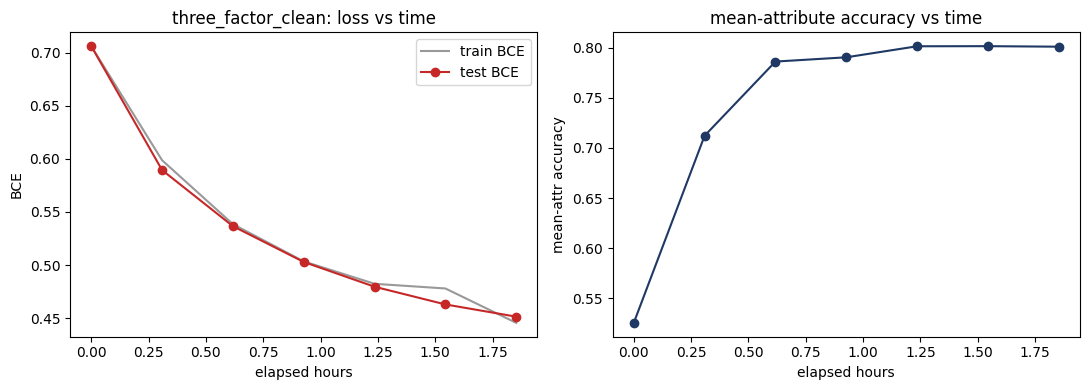

[h=1.85] step=7 test_bce=0.4515 mean-attr-acc=0.8010


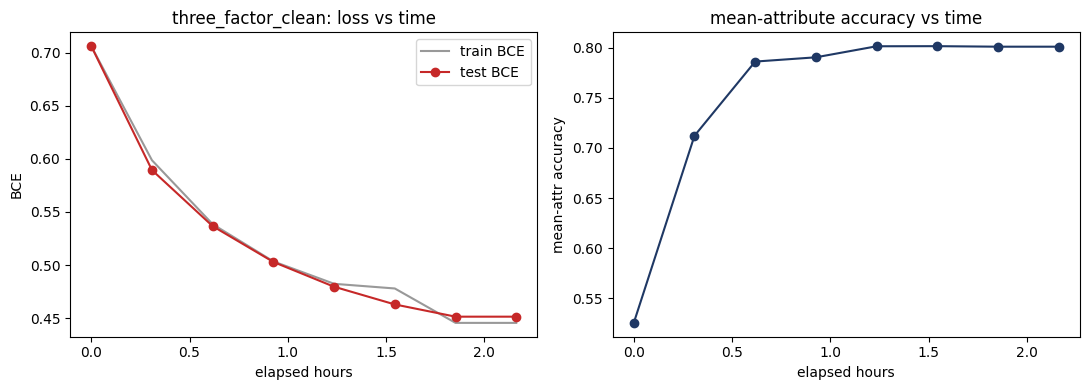

[h=2.16] step=7 test_bce=0.4515 mean-attr-acc=0.8010
wrote /content/drive/MyDrive/Section8_r1_celeba/results/three_factor_clean.json
DONE three_factor_clean: 7 steps, 2.16h, mean-attr-acc 0.8010, best BCE 0.4515


In [26]:
def write_results(step, elapsed, logs):
    te = [l[4] for l in logs]; ac = [l[5] for l in logs]
    summary = dict(initial_loss=logs[0][4], final_loss=logs[-1][4], best_loss=min(te),
                   reduction_pct=100*(logs[0][4]-min(te))/max(logs[0][4], 1e-9),
                   final_acc=logs[-1][5], best_acc=max(ac))
    peak = torch.cuda.max_memory_allocated()/1e6 if device == 'cuda' else float('nan')
    out = dict(meta=dict(method=METHOD, device=device, seed=SEED, P=P, config=CFG, note='all MEASURED-here',
                         wall_clock_sec=elapsed, total_steps=step, epochs=step*BATCH/max(Xtr.shape[0], 1), peak_mem_mb=peak),
               curve=dict(t_sec=[l[0] for l in logs], step=[l[1] for l in logs], epoch=[l[2] for l in logs],
                          train_loss=[l[3] for l in logs], test_loss=te, test_acc=ac),
               summary=summary)
    with open(RESULTS_PATH, 'w') as f: json.dump(out, f, indent=2)
    print('wrote', RESULTS_PATH)

def run():
    step, elapsed0, logs = maybe_resume()
    t0 = time.time(); budget = TIME_BUDGET_HOURS*3600
    last_ckpt = last_plot = last_log = elapsed0
    if not logs:
        l0, a0 = eval_metrics(); logs.append((elapsed0, step, 0.0, l0, l0, a0))
    tl = logs[-1][3]; printed = False
    while True:
        elapsed = elapsed0 + (time.time() - t0)
        if elapsed >= budget: break
        tl = train_step(); step += 1
        if not printed:
            dt = time.time() - t0
            print(f'[{METHOD}] step 1 = {dt:.2f}s -> ~{int(budget/max(dt,1e-9)):,} steps fit the budget.', flush=True); printed = True
        if elapsed - last_log >= LOG_EVERY_SEC:
            el, ac = eval_metrics(); logs.append((elapsed, step, step*BATCH/max(Xtr.shape[0], 1), tl, el, ac)); last_log = elapsed
        if elapsed - last_ckpt >= CKPT_EVERY_SEC:
            save_checkpoint(step, elapsed, logs); last_ckpt = elapsed
        if elapsed - last_plot >= PLOT_EVERY_SEC:
            live_plot(logs); last_plot = elapsed
    elapsed = elapsed0 + (time.time() - t0)
    el, ac = eval_metrics(); logs.append((elapsed, step, step*BATCH/max(Xtr.shape[0], 1), tl, el, ac))
    save_checkpoint(step, elapsed, logs); live_plot(logs, final=True); write_results(step, elapsed, logs)
    print(f'DONE {METHOD}: {step:,} steps, {elapsed/3600:.2f}h, mean-attr-acc {ac:.4f}, best BCE {min(l[4] for l in logs):.4f}')

run()

## How to run
- `SMOKE=True` first, then `False` → Runtime → Run all.
- Equal wall-clock; disconnect-safe (auto-resume); writes `results/<method>.json`. Loss = BCE (40-attr multi-label), metric = mean per-attribute accuracy (majority-class baseline is high). Set `CELEBA_ROOT` to the aligned-JPG folder (first run decodes a subset + caches a .pt; on Colab unzip to a local path, not Drive). Compare in `CelebA - 06_compare_results.ipynb`.